# Filtros del arreglo: análisis nodal, netlists de LTspice

Filtro de temperatura ambiente + filtro criogénico del arreglo de caracterización de junturas Josephson, resueltos por análisis nodal (Kirchhoff + matriz de admitancias) a partir de los netlists reales exportados con `LTspice.exe -netlist archivo.asc` (carpeta `LTspice/`).

**Fuente:** tensión, en todos los casos — representa la interferencia externa que el filtro debe bloquear. No es la corriente de polarización del Keithley 6620: esa, por venir de una fuente de altísima impedancia de salida, llega a la juntura casi sin atenuar sin importar el filtro, así que no es la señal relevante para esta pregunta.

**Salida:** un solo nodo, en la línea de arriba, entre la fuente y la juntura, tomado justo antes de esta — nunca una diferencia entre los dos bornes de la carga. Con la fuente normalizada a 1V, ese nodo es directamente la ganancia.

**Estructura:**
1. Filtro ambiente solo (abierto, $R_N$, $R_{sg}$, barrido en $R_{load}$)
2. Filtro criogénico solo (ídem)
3. Ambiente + cry en cadena (ídem, más $\tau$ máximo)
4. Las cuatro líneas reales (corriente + sensado)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from scipy import optimize

try:
    from IPython.display import display
except ImportError:
    display = print


def nodal_solve(nodes, stampsY, injections, ref, w):
    """Analisis nodal generico: stampsY es una lista de (nodo_a, nodo_b,
    admitancia) para cada resistencia o capacitor entre un par de nodos
    (ya evaluados a la frecuencia angular w). injections es una lista de
    (nodo, corriente_compleja) inyectada por fuentes de corriente
    ideales. 'ref' se fija a 0V -- en circuitos sin ninguna tierra real
    (como el cry) la matriz completa es singular, asi que hay que anclar
    un nodo para poder resolver (la diferencia de potencial entre otros
    dos nodos no depende de cual se elija; en circuitos CON tierra real,
    como el ambiente, 'ref' tiene que ser esa tierra, no cualquier otro
    nodo, porque ahi si importa contra que se mide)."""
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)
    Y = np.zeros((n, n), dtype=complex)
    b = np.zeros(n, dtype=complex)
    for a, c, y in stampsY:
        Y[idx[a], idx[a]] += y; Y[idx[a], idx[c]] -= y
        Y[idx[c], idx[c]] += y; Y[idx[c], idx[a]] -= y
    for a, i_val in injections:
        b[idx[a]] += i_val
    r = idx[ref]
    keep = [i for i in range(n) if i != r]
    vr = np.linalg.solve(Y[np.ix_(keep, keep)], b[keep])
    v = np.zeros(n, dtype=complex)
    for j, i in enumerate(keep):
        v[i] = vr[j]
    return dict(zip(nodes, v))


def nodal_solve_Vfuente(nodes, stampsY, terminales_fuente, ref, w):
    """Igual, pero para fuente de TENSION ideal (amplitud 1) entre los
    dos nodos de terminales_fuente -- necesita una variable de corriente
    de rama extra ('Ivs'), agregada sola a la lista de nodos. 'ref' se
    pasa siempre explicito (tiene que ser la tierra real cuando la hay,
    no un nodo cualquiera)."""
    nodes2 = nodes + ['Ivs']
    idx = {n: i for i, n in enumerate(nodes2)}
    n = len(nodes2)
    Y = np.zeros((n, n), dtype=complex)
    b = np.zeros(n, dtype=complex)
    for a, c, y in stampsY:
        Y[idx[a], idx[a]] += y; Y[idx[a], idx[c]] -= y
        Y[idx[c], idx[c]] += y; Y[idx[c], idx[a]] -= y
    vp, vn = terminales_fuente
    Y[idx[vp], idx['Ivs']] += 1; Y[idx[vn], idx['Ivs']] -= 1
    Y[idx['Ivs'], idx[vp]] += 1; Y[idx['Ivs'], idx[vn]] -= 1
    b[idx['Ivs']] = 1.0
    r = idx[ref]
    keep = [i for i in range(n) if i != r]
    vr = np.linalg.solve(Y[np.ix_(keep, keep)], b[keep])
    v = np.zeros(n, dtype=complex)
    for j, i in enumerate(keep):
        v[i] = vr[j]
    return dict(zip(nodes2, v))


def frecuencia_de_corte(fun, f_dc=1e-4):
    """-3dB de |fun(f)| respecto de su valor a muy baja frecuencia."""
    g0 = abs(fun(f_dc))
    objetivo = g0 / np.sqrt(2.0)
    return optimize.brentq(lambda f: abs(fun(f)) - objetivo, 1e-6, 1e10)


def _fmt_ing(x, pos):
    """Numeros normales con sufijo k/M/G para los ejes log (en vez de
    la notacion 10^x de matplotlib)."""
    if x <= 0:
        return "0"
    for potencia, sufijo in [(1e9, "G"), (1e6, "M"), (1e3, "k")]:
        if x >= potencia * 0.999:
            return f"{x/potencia:g}{sufijo}"
    return f"{x:g}"


def _subs_segun_rango(lo, hi):
    """Cuantos ticks por decada mostrar, segun cuantas decadas abarca
    el eje -- para que un eje angosto no quede con 2 numeros y uno
    ancho no quede saturado de etiquetas."""
    decadas = np.log10(hi / lo) if lo > 0 else 8
    if decadas > 4:
        return (1.0,)
    elif decadas > 1.5:
        return (1.0, 2.0, 5.0)
    else:
        return (1.0, 2.0, 3.0, 5.0, 7.0)


def ejes_legibles(ax, x=True, y=True):
    """Ejes log con numeros normales (1, 10, 100, 1k, 1M...) en vez de
    notacion 10^x, con densidad de ticks adaptada al rango de cada eje."""
    if x:
        subs = _subs_segun_rango(*ax.get_xlim())
        ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=subs))
        ax.xaxis.set_major_formatter(FuncFormatter(_fmt_ing))
        ax.xaxis.set_minor_formatter(NullFormatter())
    if y:
        subs = _subs_segun_rango(*ax.get_ylim())
        ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=subs))
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_ing))
        ax.yaxis.set_minor_formatter(NullFormatter())


# Tabla 5.1 de la tesis de Fran: seis canales del filtro ambiente
CANALES = pd.DataFrame({
    "canal": [1, 2, 3, 4, 5, 6],
    "R_ta_ohm": [150.0, 150.0, 51.0, 51.0, 15.0, 15.0],
    "C_ta_uF": [2.2, 1.0, 2.2, 1.0, 2.2, 1.0],
    "fc_tesis_Hz": [180.0, 396.0, 530.0, 1165.0, 1801.0, 3962.0],
})

R_cry, C_cry = 22.0, 47e-9        # filtro criogenico, todos los canales iguales
fc_cry_tesis = 35700.0            # Figura 5.8

R_N, R_sg = 500.0, 50e3           # resistencia normal / subgap de la juntura
C_J = 50e-12                      # capacidad aproximada de la juntura (Sec. 5.3)

display(CANALES)

,canal,R_ta_ohm,C_ta_uF,fc_tesis_Hz
0,1,150.0,2.2,180.0
1,2,150.0,1.0,396.0
2,3,51.0,2.2,530.0
3,4,51.0,1.0,1165.0
4,5,15.0,2.2,1801.0
5,6,15.0,1.0,3962.0


## 1. Filtro ambiente solo

### 1a. Circuito abierto, fuente de tensión

Netlist exportado con `LTspice.exe -netlist LTspice/filtro_amb_abierto.asc`:

```
R1 N002 N001 150     C1 0 N002 2.2µ
R2 N003 N002 150     C3 0 N003 2.2µ
R3 N005 N004 150     C2 N005 0  2.2µ
R4 N006 N005 150     C4 N006 0  2.2µ
V1 N001 N004 AC 1
```

Dos líneas idénticas, cada una R-C-R-C en cascada, capacitores a **tierra real** (la caja de aluminio), fuente flotante entre las dos líneas. Con fuente de tensión, $R_1$/$R_3$ **sí** importan (son un divisor real) — hay que incluirlas explícitamente en el nodal, a diferencia del caso con carga.

Se mide $V(N003)$ — la línea de arriba, en el nodo justo antes de la juntura.

In [21]:
def ganancia_amb_abierto(f_hz, R_ta, C_ta):
    """Netlist filtro_amb_abierto.asc. Nodos: N001,N004 (fuente), N002,N005
    (=Ta1,Tb1, con cap), N003,N006 (=Ta2,Tb2, con cap). Salida: N003."""
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'N001', 'N002', 'N003', 'N004', 'N005', 'N006']
    stampsY = [
        ('N001', 'N002', 1.0 / R_ta), ('N002', 'N003', 1.0 / R_ta),
        ('N004', 'N005', 1.0 / R_ta), ('N005', 'N006', 1.0 / R_ta),
        ('N002', 'GND', 1j * w * C_ta), ('N003', 'GND', 1j * w * C_ta),
        ('N005', 'GND', 1j * w * C_ta), ('N006', 'GND', 1j * w * C_ta),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('N001', 'N004'), ref='GND', w=w)
    return v['N003']


resultados = CANALES.copy()
resultados["fc_abierto_Hz"] = [
    frecuencia_de_corte(lambda f, R=f_R, C=f_C: ganancia_amb_abierto(f, R, C * 1e-6))
    for f_R, f_C in zip(resultados.R_ta_ohm, resultados.C_ta_uF)
]
resultados["dif_abierto_%"] = 100.0 * (resultados["fc_abierto_Hz"] - resultados["fc_tesis_Hz"]) / resultados["fc_tesis_Hz"]

display(resultados[["canal", "R_ta_ohm", "C_ta_uF", "fc_tesis_Hz", "fc_abierto_Hz", "dif_abierto_%"]].round(3))

,canal,R_ta_ohm,C_ta_uF,fc_tesis_Hz,fc_abierto_Hz,dif_abierto_%
0,1,150.0,2.2,180.0,180.491,0.273
1,2,150.0,1.0,396.0,397.080,0.273
2,3,51.0,2.2,530.0,530.856,0.161
3,4,51.0,1.0,1165.0,1167.883,0.247
4,5,15.0,2.2,1801.0,1804.909,0.217
5,6,15.0,1.0,3962.0,3970.801,0.222


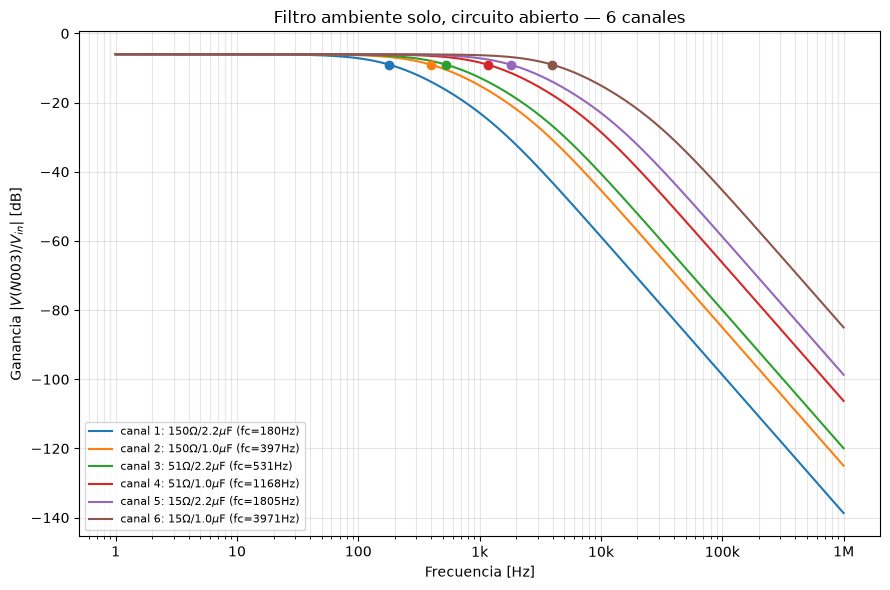

In [22]:
frecuencias = np.logspace(0, 6, 800)

fig, ax = plt.subplots(figsize=(9, 6))
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    ganancia_db = 20 * np.log10([abs(ganancia_amb_abierto(f, R_ta, C_ta)) for f in frecuencias])
    g0_db = 20 * np.log10(abs(ganancia_amb_abierto(1e-4, R_ta, C_ta)))
    etiqueta = f"canal {fila.canal}: {R_ta:.0f}$\\Omega$/{fila.C_ta_uF:.1f}$\\mu$F (fc={fila.fc_abierto_Hz:.0f}Hz)"
    linea, = ax.semilogx(frecuencias, ganancia_db, label=etiqueta)
    ax.scatter(fila.fc_abierto_Hz, g0_db - 3.0, color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia $|V(N003)/V_{in}|$ [dB]")
ax.set_title("Filtro ambiente solo, circuito abierto — 6 canales")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax, y=False)
plt.tight_layout()
plt.show()

### 1b. Con la juntura conectada ($R_N$ o $R_{sg}$)

Mismo netlist que 1a, con la carga puesta (igual que `filtro_amb_conRC.asc`):

```
R1 N002 N001 150     C1 0 N002 2.2µ
R2 N003 N002 150     C3 0 N003 2.2µ
R3 N005 N004 150     C2 N005 0  2.2µ
R4 N006 N005 150     C4 N006 0  2.2µ
R5 N003 N006 500     (carga: R_N o R_sg)
C5 N003 N006 50p     (carga: C_J)
V1 N001 N004 AC 1
```

**Salida:** $V(N003)$, un solo nodo, línea de arriba, justo antes de la juntura. Nunca se lee $N006$.

In [23]:
def V_amb_carga(f_hz, R_ta, C_ta, R_load, C_load):
    """Netlist filtro_amb_conRC.asc. Salida: V(N003), un solo nodo,
    linea de arriba, justo antes de la juntura. Nunca se lee N006."""
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'N001', 'N002', 'N003', 'N004', 'N005', 'N006']
    Yload = 1.0 / R_load + 1j * w * C_load
    stampsY = [
        ('N001', 'N002', 1.0 / R_ta), ('N002', 'N003', 1.0 / R_ta),
        ('N004', 'N005', 1.0 / R_ta), ('N005', 'N006', 1.0 / R_ta),
        ('N002', 'GND', 1j * w * C_ta), ('N003', 'GND', 1j * w * C_ta),
        ('N005', 'GND', 1j * w * C_ta), ('N006', 'GND', 1j * w * C_ta),
        ('N003', 'N006', Yload),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('N001', 'N004'), ref='GND', w=w)
    return v['N003']


filas = []
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    d = {"canal": fila.canal, "fc_abierto_Hz": fila.fc_abierto_Hz}
    for nombre, R_load in [("fc_R_N_Hz", R_N), ("fc_R_sg_Hz", R_sg)]:
        d[nombre] = frecuencia_de_corte(lambda f, Rl=R_load: V_amb_carga(f, R_ta, C_ta, Rl, C_J))
    filas.append(d)

tabla_amb_carga = pd.DataFrame(filas)
display(tabla_amb_carga.round(4))

,canal,fc_abierto_Hz,fc_R_N_Hz,fc_R_sg_Hz
0,1,180.4909,351.8684,182.4580
1,2,397.0801,774.0861,401.3921
2,3,530.8557,719.4133,532.8132
3,4,1167.8826,1582.6522,1172.1440
4,5,1804.9094,1999.7781,1806.8267
5,6,3970.8008,4399.3456,3974.8656


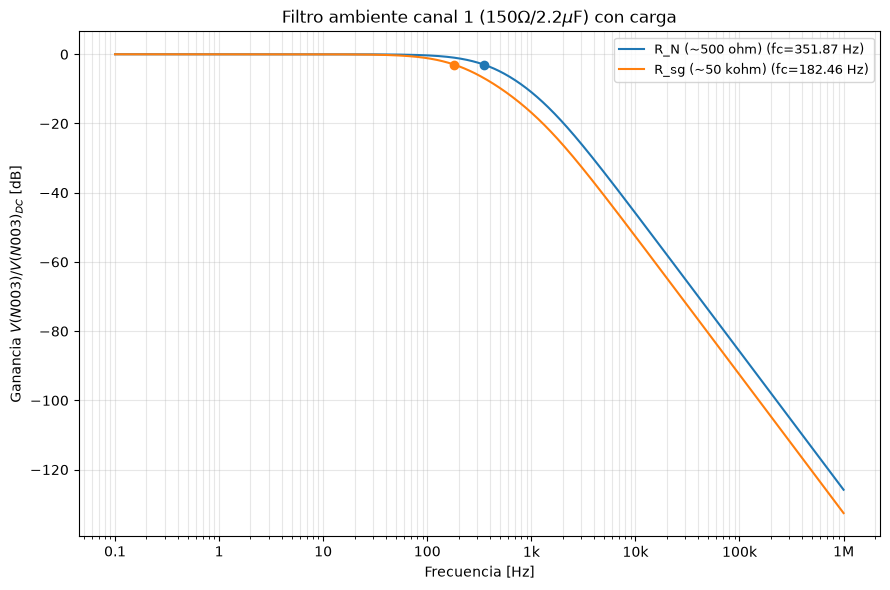

In [24]:
frecuencias_z = np.logspace(-1, 6, 800)
fila1 = resultados.iloc[0]
R_ta1, C_ta1 = fila1.R_ta_ohm, fila1.C_ta_uF * 1e-6

fig, ax = plt.subplots(figsize=(9, 6))
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    g0 = abs(V_amb_carga(1e-4, R_ta1, C_ta1, R_load, C_J))
    vals_db = 20 * np.log10(np.array([abs(V_amb_carga(f, R_ta1, C_ta1, R_load, C_J)) for f in frecuencias_z]) / g0)
    fc = frecuencia_de_corte(lambda f: V_amb_carga(f, R_ta1, C_ta1, R_load, C_J))
    linea, = ax.semilogx(frecuencias_z, vals_db, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, -3.0, color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"Ganancia $V(N003)/V(N003)_{DC}$ [dB]")
ax.set_title(f"Filtro ambiente canal {fila1.canal:.0f} ({R_ta1:.0f}$\\Omega$/{C_ta1*1e6:.1f}$\\mu$F) con carga")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax, y=False)
plt.tight_layout()
plt.show()

### 1c. Barrido en $R_{load}$

Mismo circuito y salida que en 1b, barriendo $R_{load}$. A $R_{load}\to\infty$ converge al $f_c$ del caso abierto.

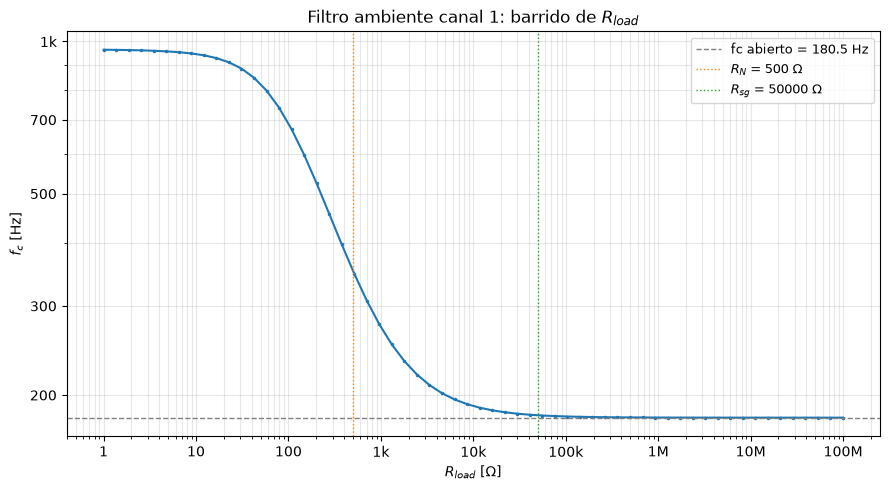

In [25]:
R_loads_barrido = np.logspace(0, 8, 60)
fcs_barrido = [frecuencia_de_corte(lambda f: V_amb_carga(f, R_ta1, C_ta1, Rl, C_J)) for Rl in R_loads_barrido]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(R_loads_barrido, fcs_barrido, marker='.', markersize=3)
ax.axhline(fila1.fc_abierto_Hz, color="gray", linestyle="--", linewidth=1, label=f"fc abierto = {fila1.fc_abierto_Hz:.1f} Hz")
ax.axvline(R_N, color="C1", linestyle=":", linewidth=1, label=f"$R_N$ = {R_N:.0f} $\\Omega$")
ax.axvline(R_sg, color="C2", linestyle=":", linewidth=1, label=f"$R_{{sg}}$ = {R_sg:.0f} $\\Omega$")
ax.set_xlabel(r"$R_{load}$ [$\Omega$]")
ax.set_ylabel("$f_c$ [Hz]")
ax.set_title(f"Filtro ambiente canal {fila1.canal:.0f}: barrido de $R_{{load}}$")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax)
plt.tight_layout()
plt.show()

## 2. Filtro criogénico solo

### 2a. Circuito abierto, fuente de tensión

Netlist de `LTspice/filtro_cry_abierto.asc`:

```
R1 N002 N001 22      (Vin_p -> Ta1)
R2 N003 N002 22      (Ta1 -> Ta2)
R3 NC_01 N003 22     (Ta2 -> outp, sin conectar: circuito abierto)
R4 N005 N004 22      (Vin_n -> Tb1)
R5 N006 N005 22      (Tb1 -> Tb2)
R6 NC_02 N006 22     (Tb2 -> outn, sin conectar: circuito abierto)
C1 N002 N005 47n     (Ta1 <-> Tb1, entre líneas)
C2 N003 N006 47n     (Ta2 <-> Tb2, entre líneas)
V1 N001 N004 AC 1
```


In [26]:
def ganancia_cry_abierto(f_hz, R, C):
    """Netlist filtro_cry_abierto.asc. R3,R6 (a NC) se omiten -- no
    llevan corriente. Referencia: N004 (retorno de la fuente)."""
    w = 2.0 * np.pi * f_hz
    nodes = ['N004', 'N001', 'Ta1', 'Ta2', 'Tb1', 'Tb2']
    stampsY = [
        ('N001', 'Ta1', 1.0 / R), ('Ta1', 'Ta2', 1.0 / R),
        ('N004', 'Tb1', 1.0 / R), ('Tb1', 'Tb2', 1.0 / R),
        ('Ta1', 'Tb1', 1j * w * C), ('Ta2', 'Tb2', 1j * w * C),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('N001', 'N004'), ref='N004', w=w)
    return v['Ta2']


fc_cry_abierto = frecuencia_de_corte(lambda f: ganancia_cry_abierto(f, R_cry, C_cry))
print(f"fc modelo = {fc_cry_abierto:.2f} Hz   fc tesis (Fig. 5.8) = {fc_cry_tesis:.0f} Hz"
      f"   diferencia = {100*(fc_cry_abierto-fc_cry_tesis)/fc_cry_tesis:.2f}%")

fc modelo = 35850.07 Hz   fc tesis (Fig. 5.8) = 35700 Hz   diferencia = 0.42%


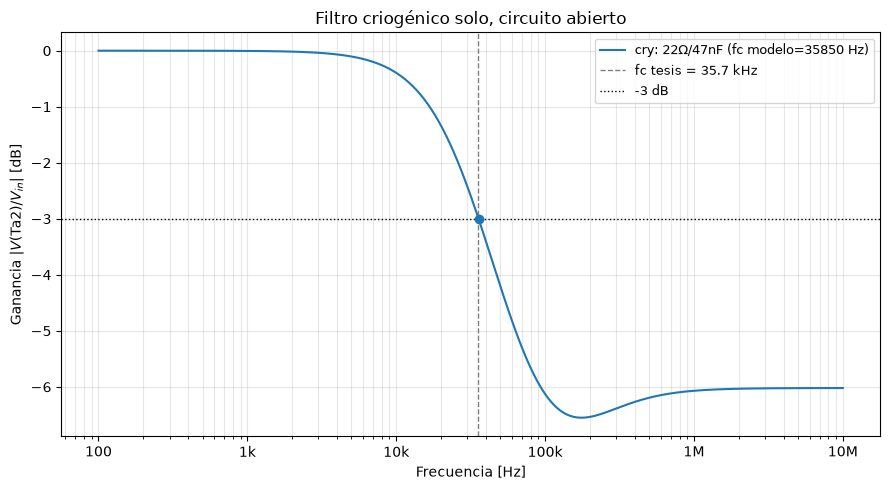

In [27]:
frecuencias_cry = np.logspace(2, 7, 800)
ganancia_db_cry = 20 * np.log10([abs(ganancia_cry_abierto(f, R_cry, C_cry)) for f in frecuencias_cry])
g0_db_cry = 20 * np.log10(abs(ganancia_cry_abierto(1e-4, R_cry, C_cry)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(frecuencias_cry, ganancia_db_cry, label=f"cry: 22$\\Omega$/47nF (fc modelo={fc_cry_abierto:.0f} Hz)")
ax.scatter(fc_cry_abierto, g0_db_cry - 3.0, color="C0", zorder=5)
ax.axvline(fc_cry_tesis, color="gray", linestyle="--", linewidth=1, label=f"fc tesis = {fc_cry_tesis/1e3:.1f} kHz")
ax.axhline(g0_db_cry - 3.0, color="black", linestyle=":", linewidth=1, label="-3 dB")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia $|V(\\mathrm{Ta2})/V_{in}|$ [dB]")
ax.set_title("Filtro criogénico solo, circuito abierto")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax, y=False)
plt.tight_layout()
plt.show()

### 2b. Con la juntura conectada

Netlist `filtro_cry_conCR.asc`:

```
R1 N002 N001 22      R4 N006 N005 22
R2 N003 N002 22      R5 N007 N006 22
R3 N004 N003 22      R6 N008 N007 22
C1 N002 N006 47n     (entre líneas)
C2 N003 N007 47n     (entre líneas)
R7 N004 N008 500     (carga: R_N o R_sg)
C3 N004 N008 50p     (carga: C_J)
V1 N001 N005 AC 1
```

Tres etapas de R por línea antes de la carga.

**Salida:** $V(\mathrm{outp})=V(N004)$, un solo nodo, línea de arriba, justo antes de la juntura. Nunca se lee $\mathrm{outn}$/$N008$.

In [28]:
def V_cry_carga(f_hz, R, C, R_load, C_load):
    """Netlist filtro_cry_conCR.asc. Tres etapas por linea
    (N001-R1-Ta1-R2-Ta2-R3-outp), carga entre outp/outn. Salida:
    V(outp), un solo nodo. Nunca se lee outn."""
    w = 2.0 * np.pi * f_hz
    nodes = ['N001', 'Ta1', 'Ta2', 'outp', 'N005', 'Tb1', 'Tb2', 'outn']
    Yload = 1.0 / R_load + 1j * w * C_load
    stampsY = [
        ('N001', 'Ta1', 1.0 / R), ('Ta1', 'Ta2', 1.0 / R), ('Ta2', 'outp', 1.0 / R),
        ('N005', 'Tb1', 1.0 / R), ('Tb1', 'Tb2', 1.0 / R), ('Tb2', 'outn', 1.0 / R),
        ('Ta1', 'Tb1', 1j * w * C), ('Ta2', 'Tb2', 1j * w * C),
        ('outp', 'outn', Yload),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('N001', 'N005'), ref='N005', w=w)
    return v['outp']


tabla_cry_carga = pd.DataFrame({
    "carga": ["R_N (~500 ohm)", "R_sg (~50 kohm)"],
    "R_load_ohm": [R_N, R_sg],
})
tabla_cry_carga["fc_Hz"] = [
    frecuencia_de_corte(lambda f, Rl=Rl: V_cry_carga(f, R_cry, C_cry, Rl, C_J))
    for Rl in tabla_cry_carga["R_load_ohm"]
]
tabla_cry_carga["fc_abierto_Hz"] = fc_cry_abierto
display(tabla_cry_carga.round(3))

,carga,R_load_ohm,fc_Hz,fc_abierto_Hz
0,R_N (~500 ohm),500.0,44810.176,35850.071
1,R_sg (~50 kohm),50000.0,35900.608,35850.071


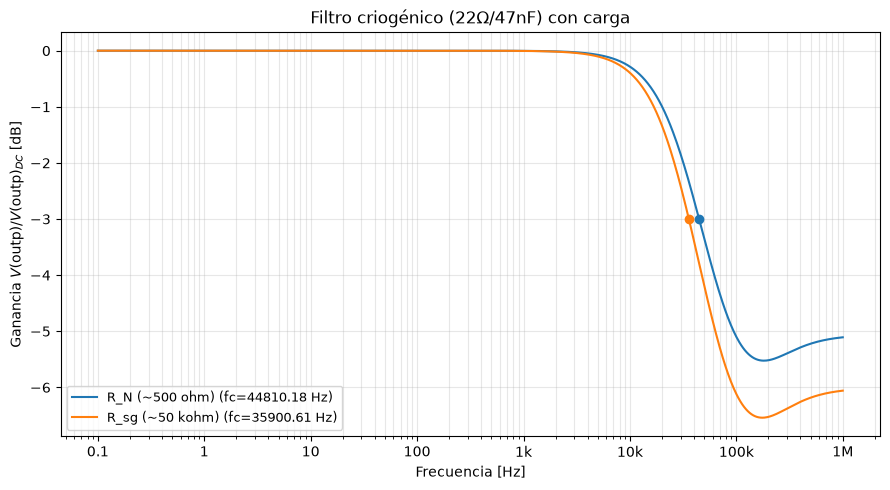

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    g0 = abs(V_cry_carga(1e-4, R_cry, C_cry, R_load, C_J))
    vals_db = 20 * np.log10(np.array([abs(V_cry_carga(f, R_cry, C_cry, R_load, C_J)) for f in frecuencias_z]) / g0)
    fc = frecuencia_de_corte(lambda f: V_cry_carga(f, R_cry, C_cry, R_load, C_J))
    linea, = ax.semilogx(frecuencias_z, vals_db, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, -3.0, color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"Ganancia $V(\mathrm{outp})/V(\mathrm{outp})_{DC}$ [dB]")
ax.set_title("Filtro criogénico (22$\\Omega$/47nF) con carga")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax, y=False)
plt.tight_layout()
plt.show()

### 2c. Barrido en $R_{load}$

Mismo circuito y misma salida que en 2b ($V(\mathrm{outp})$, un solo nodo, antes de la juntura), barriendo $R_{load}$.

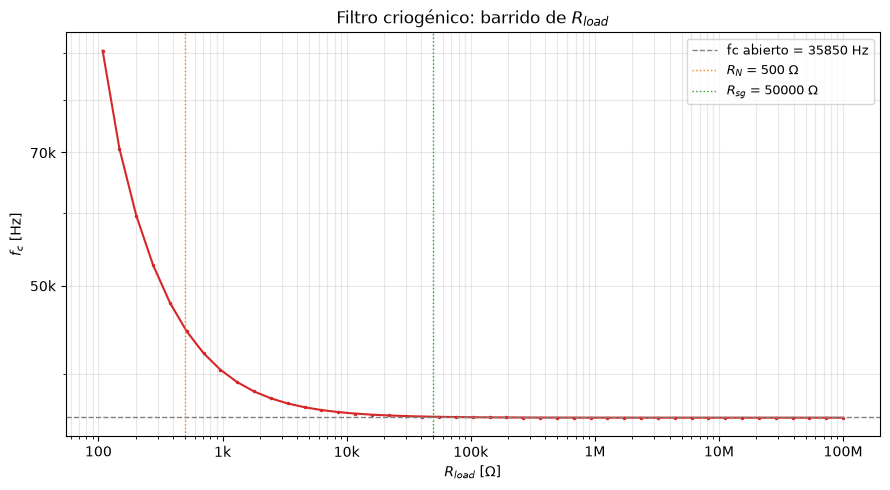

In [30]:
def fc_seguro(fun):
    """Como frecuencia_de_corte, pero devuelve NaN si no hay cruce de
    -3dB en el rango (pasa con R_load chico en el cry: la ganancia no
    baja a cero en alta frecuencia por la topologia diferencial, queda
    en un piso de 0.5)."""
    try:
        return frecuencia_de_corte(fun)
    except ValueError:
        return np.nan

R_loads_barrido_cry = np.logspace(0, 8, 60)
fcs_barrido_cry = [fc_seguro(lambda f: V_cry_carga(f, R_cry, C_cry, Rl, C_J)) for Rl in R_loads_barrido_cry]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(R_loads_barrido_cry, fcs_barrido_cry, marker='.', markersize=3, color="C3")
ax.axhline(fc_cry_abierto, color="gray", linestyle="--", linewidth=1, label=f"fc abierto = {fc_cry_abierto:.0f} Hz")
ax.axvline(R_N, color="C1", linestyle=":", linewidth=1, label=f"$R_N$ = {R_N:.0f} $\\Omega$")
ax.axvline(R_sg, color="C2", linestyle=":", linewidth=1, label=f"$R_{{sg}}$ = {R_sg:.0f} $\\Omega$")
ax.set_xlabel(r"$R_{load}$ [$\Omega$]")
ax.set_ylabel("$f_c$ [Hz]")
ax.set_title("Filtro criogénico: barrido de $R_{load}$")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax)
plt.tight_layout()
plt.show()

## 3. Ambiente + criogénico en cadena, dos líneas

### 3a. Circuito abierto, fuente de tensión

Netlist de `LTspice/2lineas_abierto.asc`:

```
R7 N002 N001 150     R9 N007 N006 150      (ambiente, tierra real)
R8 N003 N002 150     R10 N008 N007 150
C3 0 N002 2.2µ       C5 N007 0 2.2µ
C4 0 N003 2.2µ       C6 N008 0 2.2µ
R1 N004 N003 22      R4 N009 N008 22       (cry, arranca donde termina el ambiente)
R2 N005 N004 22      R5 N010 N009 22
R3 NC_01 N005 22     R6 NC_02 N010 22      (abierto)
C1 N004 N009 47n     (entre líneas)
C2 N005 N010 47n     (entre líneas)
V1 N001 N006 AC 1
```

El ambiente (con tierra real) alimenta, a través de las resistencias del criogénico, la salida abierta. Con fuente de tensión hay que incluir $R_7$/$R_9$ explícitas.

In [31]:
def ganancia_completo_abierto(f_hz, R_ta, C_ta, R_cry, C_cry):
    """Netlist 2lineas_abierto.asc. Ambiente: N001(driven)-R7-N002(cap)
    -R8-N003(cap). Cry: N003-R1-N004(bridge)-R2-N005(bridge)-R3-NC
    (abierto). Salida: N005."""
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'N001', 'N002', 'N003', 'N004', 'N005',
              'N006', 'N007', 'N008', 'N009', 'N010']
    stampsY = [
        ('N001', 'N002', 1.0 / R_ta), ('N002', 'N003', 1.0 / R_ta),
        ('N006', 'N007', 1.0 / R_ta), ('N007', 'N008', 1.0 / R_ta),
        ('N002', 'GND', 1j * w * C_ta), ('N003', 'GND', 1j * w * C_ta),
        ('N007', 'GND', 1j * w * C_ta), ('N008', 'GND', 1j * w * C_ta),
        ('N003', 'N004', 1.0 / R_cry), ('N004', 'N005', 1.0 / R_cry),
        ('N008', 'N009', 1.0 / R_cry), ('N009', 'N010', 1.0 / R_cry),
        ('N004', 'N009', 1j * w * C_cry), ('N005', 'N010', 1j * w * C_cry),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('N001', 'N006'), ref='GND', w=w)
    return v['N005']


filas = []
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    fc = frecuencia_de_corte(lambda f: ganancia_completo_abierto(f, R_ta, C_ta, R_cry, C_cry))
    filas.append({"canal": fila.canal, "fc_ambiente_solo_Hz": fila.fc_abierto_Hz, "fc_completo_abierto_Hz": fc})

tabla_completo = pd.DataFrame(filas)
tabla_completo["dif_vs_ambiente_%"] = 100.0 * (tabla_completo["fc_completo_abierto_Hz"] - tabla_completo["fc_ambiente_solo_Hz"]) / tabla_completo["fc_ambiente_solo_Hz"]
display(tabla_completo.round(3))

# El tau de la tesis es del ARREGLO COMPLETO (ambiente+cry), pero la
# tesis lo estima con la aproximacion de polo dominante: "el filtrado
# completo tiene una fc dominada por la etapa de temperatura ambiente"
# -- es decir, usan el fc del ambiente solo como aproximacion del fc
# del sistema completo. Por eso el de "ambiente solo" da casi exacto
# contra el 0.88ms de la tesis; el de "arreglo completo" es el numero
# exacto de la cadena (sale un poco mas alto porque encadenar dos
# filtros baja el fc un poco mas de lo que la aproximacion captura).
tau_ms_amb = 1000.0 / (2 * np.pi * tabla_completo["fc_ambiente_solo_Hz"].min())
tau_ms_completo = 1000.0 / (2 * np.pi * tabla_completo["fc_completo_abierto_Hz"].min())
print(f"tau, aprox. polo dominante (fc del ambiente solo) = {tau_ms_amb:.4f} ms")
print(f"tau, arreglo completo exacto (ambiente+cry)       = {tau_ms_completo:.4f} ms")
print("tau tesis (arreglo completo, estimado con la aprox. de polo dominante) = 0.88 ms")

,canal,fc_ambiente_solo_Hz,fc_completo_abierto_Hz,dif_vs_ambiente_%
0,1,180.491,170.126,-5.743
1,2,397.080,349.728,-11.925
2,3,530.856,499.912,-5.829
3,4,1167.883,1024.724,-12.258
4,5,1804.909,1690.712,-6.327
5,6,3970.801,3411.565,-14.084


tau, aprox. polo dominante (fc del ambiente solo) = 0.8818 ms
tau, arreglo completo exacto (ambiente+cry)       = 0.9355 ms
tau tesis (arreglo completo, estimado con la aprox. de polo dominante) = 0.88 ms


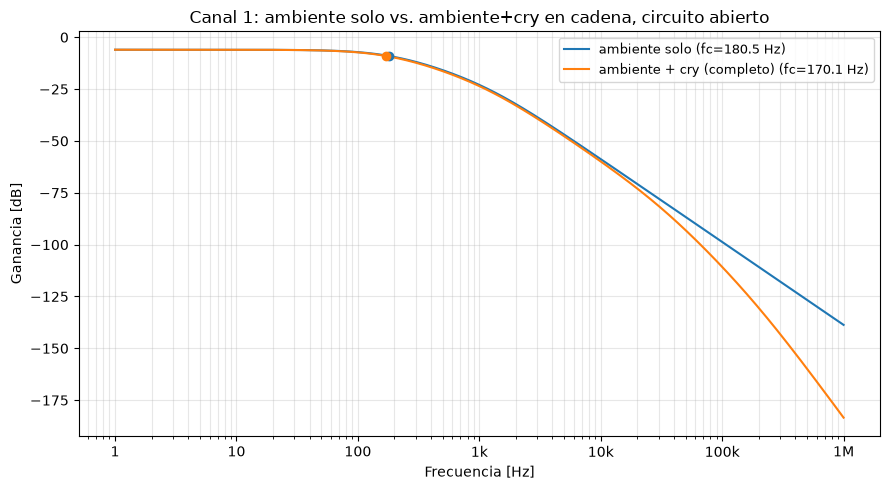

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, fun, fc in [
    ("ambiente solo", lambda f: ganancia_amb_abierto(f, 150.0, 2.2e-6), tabla_completo.loc[tabla_completo.canal == 1, "fc_ambiente_solo_Hz"].iloc[0]),
    ("ambiente + cry (completo)", lambda f: ganancia_completo_abierto(f, 150.0, 2.2e-6, R_cry, C_cry), tabla_completo.loc[tabla_completo.canal == 1, "fc_completo_abierto_Hz"].iloc[0]),
]:
    ganancia_db = 20 * np.log10([abs(fun(f)) for f in frecuencias])
    g0_db = 20 * np.log10(abs(fun(1e-4)))
    linea, = ax.semilogx(frecuencias, ganancia_db, label=f"{nombre} (fc={fc:.1f} Hz)")
    ax.scatter(fc, g0_db - 3.0, color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia [dB]")
ax.set_title("Canal 1: ambiente solo vs. ambiente+cry en cadena, circuito abierto")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax, y=False)
plt.tight_layout()
plt.show()

### 3b. Con la juntura conectada

Netlist `2lineas_conRC.asc`:

```
R7 N002 N001 150     R9 N008 N007 150      (ambiente, tierra real)
R8 N003 N002 150     R10 N009 N008 150
C3 0 N002 2.2µ       C5 N008 0 2.2µ
C4 0 N003 2.2µ       C6 N009 0 2.2µ
R1 N004 N003 22      R4 N010 N009 22       (cry, 3 etapas)
R2 N005 N004 22      R5 N011 N010 22
R3 N006 N005 22      R6 N012 N011 22
C1 N004 N010 47n     (entre líneas)
C2 N005 N011 47n     (entre líneas)
R21 N006 N012 50k    (carga: R_N o R_sg)
C13 N006 N012 50p    (carga: C_J)
V1 N001 N007 AC 1
```

**Salida:** $V(N006)$, un solo nodo, línea de arriba, justo antes de la juntura. Nunca se lee $N012$.

In [33]:
def V_completo_carga(f_hz, R_ta, C_ta, R_cry, C_cry, R_load, C_load):
    """Netlist 2lineas_conRC.asc. Ambiente: N001-R7-N002(cap)-R8-N003(cap).
    Cry, 3 etapas: N003-R1-N004(bridge)-R2-N005(bridge)-R3-N006(carga).
    Salida: V(N006), un solo nodo. Nunca se lee N012."""
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'N001', 'N002', 'N003', 'N004', 'N005', 'N006',
              'N007', 'N008', 'N009', 'N010', 'N011', 'N012']
    Yload = 1.0 / R_load + 1j * w * C_load
    stampsY = [
        ('N001', 'N002', 1.0 / R_ta), ('N002', 'N003', 1.0 / R_ta),
        ('N007', 'N008', 1.0 / R_ta), ('N008', 'N009', 1.0 / R_ta),
        ('N002', 'GND', 1j * w * C_ta), ('N003', 'GND', 1j * w * C_ta),
        ('N008', 'GND', 1j * w * C_ta), ('N009', 'GND', 1j * w * C_ta),
        ('N003', 'N004', 1.0 / R_cry), ('N004', 'N005', 1.0 / R_cry), ('N005', 'N006', 1.0 / R_cry),
        ('N009', 'N010', 1.0 / R_cry), ('N010', 'N011', 1.0 / R_cry), ('N011', 'N012', 1.0 / R_cry),
        ('N004', 'N010', 1j * w * C_cry), ('N005', 'N011', 1j * w * C_cry),
        ('N006', 'N012', Yload),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('N001', 'N007'), ref='GND', w=w)
    return v['N006']


filas = []
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    d = {"canal": fila.canal, "fc_completo_abierto_Hz": tabla_completo.loc[tabla_completo.canal == fila.canal, "fc_completo_abierto_Hz"].iloc[0]}
    for nombre, R_load in [("fc_R_N_Hz", R_N), ("fc_R_sg_Hz", R_sg)]:
        d[nombre] = frecuencia_de_corte(lambda f, Rl=R_load: V_completo_carga(f, R_ta, C_ta, R_cry, C_cry, Rl, C_J))
    filas.append(d)

tabla_completo_carga = pd.DataFrame(filas)
display(tabla_completo_carga.round(4))

,canal,fc_completo_abierto_Hz,fc_R_N_Hz,fc_R_sg_Hz
0,1,170.1260,307.3968,172.0190
1,2,349.7283,644.0983,353.6993
2,3,499.9121,650.6480,501.8439
3,4,1024.7241,1353.3606,1028.8446
4,5,1690.7116,1859.6263,1692.7848
5,6,3411.5652,3810.3625,3416.2371


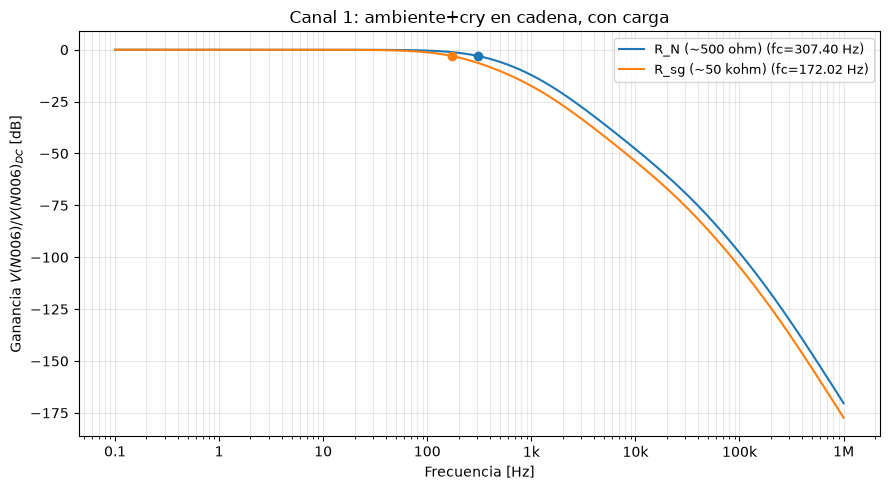

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    g0 = abs(V_completo_carga(1e-4, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J))
    vals_db = 20 * np.log10(np.array([abs(V_completo_carga(f, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J)) for f in frecuencias_z]) / g0)
    fc = frecuencia_de_corte(lambda f: V_completo_carga(f, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J))
    linea, = ax.semilogx(frecuencias_z, vals_db, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, -3.0, color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"Ganancia $V(N006)/V(N006)_{DC}$ [dB]")
ax.set_title("Canal 1: ambiente+cry en cadena, con carga")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
ejes_legibles(ax, y=False)
plt.tight_layout()
plt.show()

### 3c. Barrido en $R_{load}$, y $\tau$ correspondiente

Mismo circuito y misma salida que en 3b, barriendo $R_{load}$, junto con $\tau=1/(2\pi f_c)$ para cada punto.

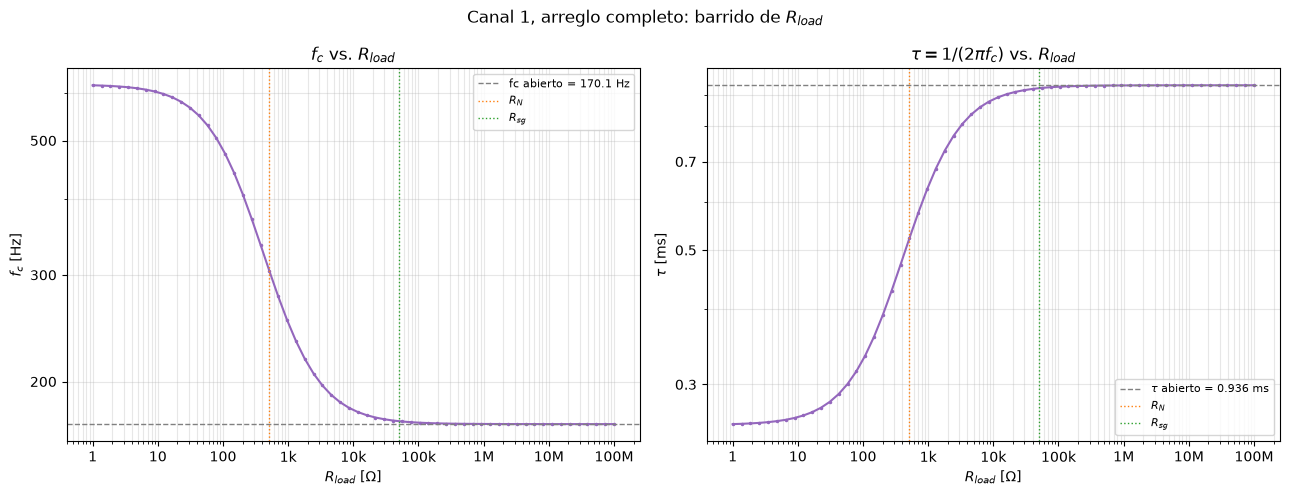

In [35]:
R_loads_barrido_c = np.logspace(0, 8, 60)
fc_completo_abierto_c1 = tabla_completo.loc[tabla_completo.canal == 1, "fc_completo_abierto_Hz"].iloc[0]
fcs_barrido_c = [fc_seguro(lambda f: V_completo_carga(f, 150.0, 2.2e-6, R_cry, C_cry, Rl, C_J)) for Rl in R_loads_barrido_c]
taus_barrido_c = 1000.0 / (2 * np.pi * np.array(fcs_barrido_c))

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].loglog(R_loads_barrido_c, fcs_barrido_c, marker='.', markersize=3, color="C4")
axs[0].axhline(fc_completo_abierto_c1, color="gray", linestyle="--", linewidth=1, label=f"fc abierto = {fc_completo_abierto_c1:.1f} Hz")
axs[0].axvline(R_N, color="C1", linestyle=":", linewidth=1, label=f"$R_N$")
axs[0].axvline(R_sg, color="C2", linestyle=":", linewidth=1, label=f"$R_{{sg}}$")
axs[0].set_xlabel(r"$R_{load}$ [$\Omega$]")
axs[0].set_ylabel("$f_c$ [Hz]")
axs[0].set_title("$f_c$ vs. $R_{load}$")
axs[0].legend(fontsize=8)
axs[0].grid(alpha=0.3, which="both")
ejes_legibles(axs[0])

axs[1].loglog(R_loads_barrido_c, taus_barrido_c, marker='.', markersize=3, color="C4")
axs[1].axhline(tau_ms_completo, color="gray", linestyle="--", linewidth=1, label=f"$\\tau$ abierto = {tau_ms_completo:.3f} ms")
axs[1].axvline(R_N, color="C1", linestyle=":", linewidth=1, label=f"$R_N$")
axs[1].axvline(R_sg, color="C2", linestyle=":", linewidth=1, label=f"$R_{{sg}}$")
axs[1].set_xlabel(r"$R_{load}$ [$\Omega$]")
axs[1].set_ylabel(r"$\tau$ [ms]")
axs[1].set_title(r"$\tau=1/(2\pi f_c)$ vs. $R_{load}$")
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3, which="both")
ejes_legibles(axs[1])

fig.suptitle("Canal 1, arreglo completo: barrido de $R_{load}$")
plt.tight_layout()
plt.show()

## 4. Las cuatro líneas reales

Netlist `completo_conRC.asc` — línea de corriente (fuente y carga) y línea de sensado (misma estructura, sin fuente propia, compartiendo $jp$/$jn$ con la de corriente):

```
Línea de corriente:                  Línea de sensado:
R7 N002 N001 150   R9 N007 N006 150  R17 N012 N011 150  R19 N017 N016 150
R8 N003 N002 150   R10 N008 N007 150 R18 N013 N012 150  R20 N018 N017 150
C3 0 N002 2.2µ      C5 N007 0 2.2µ    C9 0 N012 2.2µ      C11 N017 0 2.2µ
C4 0 N003 2.2µ      C6 N008 0 2.2µ    C10 0 N013 2.2µ     C12 N018 0 2.2µ
R1 N004 N003 22    R4 N009 N008 22    R11 N014 N013 22    R14 N019 N018 22
R2 N005 N004 22    R5 N010 N009 22    R12 N015 N014 22    R15 N020 N019 22
R3 jp N005 22      R6 jn N010 22      R13 jp N015 22      R16 jn N020 22
C1 N004 N009 47n (entre líneas)       C7 N014 N019 47n (entre líneas)
C2 N005 N010 47n (entre líneas)       C8 N015 N020 47n (entre líneas)

R22 N011 N016 1G   (referencia numérica para la línea de sensado)
R21 jp jn 50k    C13 jp jn 50p   (carga, compartida por las dos líneas)
V1 N001 N006 AC 1   (solo la línea de corriente tiene fuente)
```

La línea de sensado no tiene fuente propia, pero sigue en el circuito y afecta a $jp$/$jn$ a través de sus propios capacitores.

**Salida:** $V(jp)$, un solo nodo, línea de corriente, justo antes de la juntura. Nunca se lee $jn$.

A $R_{load}\to\infty$, $V(jp)$ acá no converge al caso abierto de la Sección 3 (170,1 Hz): la línea de sensado, al tener su propio filtro completo con sus propios capacitores, aporta un camino de fuga entre $jp$ y $jn$ independiente de $R_{load}$.

In [36]:
def cuatro_lineas(f_hz, R_ta, C_ta, R_cry, C_cry, R_load, C_load):
    """Netlist completo_conRC.asc. R22 (1G) entre los dos extremos de
    la linea de sensado (Sfar_a,Sfar_b) -- esa linea no tiene fuente
    propia, pero sigue en el circuito y afecta jp/jn a traves de sus
    propios capacitores. Salida: V(jp), un solo nodo, linea de
    corriente, justo antes de la juntura. Nunca se lee jn."""
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'Vin_p', 'Ta1', 'Ta2', 'Ca1', 'Ca2', 'jp',
              'Vin_n', 'Tb1', 'Tb2', 'Cb1', 'Cb2', 'jn',
              'Sfar_a', 'Sa1', 'Sa2', 'Sca1', 'Sca2', 'Sfar_b', 'Sb1', 'Sb2', 'Scb1', 'Scb2']
    Yload = 1.0 / R_load + 1j * w * C_load
    stampsY = [
        ('Vin_p', 'Ta1', 1.0 / R_ta), ('Ta1', 'Ta2', 1.0 / R_ta),
        ('Vin_n', 'Tb1', 1.0 / R_ta), ('Tb1', 'Tb2', 1.0 / R_ta),
        ('Ta1', 'GND', 1j * w * C_ta), ('Ta2', 'GND', 1j * w * C_ta),
        ('Tb1', 'GND', 1j * w * C_ta), ('Tb2', 'GND', 1j * w * C_ta),
        ('Ta2', 'Ca1', 1.0 / R_cry), ('Ca1', 'Ca2', 1.0 / R_cry), ('Ca2', 'jp', 1.0 / R_cry),
        ('Tb2', 'Cb1', 1.0 / R_cry), ('Cb1', 'Cb2', 1.0 / R_cry), ('Cb2', 'jn', 1.0 / R_cry),
        ('Ca1', 'Cb1', 1j * w * C_cry), ('Ca2', 'Cb2', 1j * w * C_cry),
        ('jp', 'jn', Yload),
        ('Sfar_a', 'Sa1', 1.0 / R_ta), ('Sfar_b', 'Sb1', 1.0 / R_ta),
        ('Sfar_a', 'Sfar_b', 1.0 / 1e9),
        ('Sa1', 'Sa2', 1.0 / R_ta), ('Sb1', 'Sb2', 1.0 / R_ta),
        ('Sa1', 'GND', 1j * w * C_ta), ('Sa2', 'GND', 1j * w * C_ta),
        ('Sb1', 'GND', 1j * w * C_ta), ('Sb2', 'GND', 1j * w * C_ta),
        ('Sa2', 'Sca1', 1.0 / R_cry), ('Sca1', 'Sca2', 1.0 / R_cry), ('Sca2', 'jp', 1.0 / R_cry),
        ('Sb2', 'Scb1', 1.0 / R_cry), ('Scb1', 'Scb2', 1.0 / R_cry), ('Scb2', 'jn', 1.0 / R_cry),
        ('Sca1', 'Scb1', 1j * w * C_cry), ('Sca2', 'Scb2', 1j * w * C_cry),
    ]
    v = nodal_solve_Vfuente(nodes, stampsY, ('Vin_p', 'Vin_n'), ref='GND', w=w)
    return v['jp']


filas = []
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    fc_jp = frecuencia_de_corte(lambda f: cuatro_lineas(f, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J))
    filas.append({"carga": nombre, "fc_Hz": fc_jp})

tabla_4lineas = pd.DataFrame(filas)
display(tabla_4lineas.round(3))

,carga,fc_Hz
0,R_N (~500 ohm),126.116
1,R_sg (~50 kohm),58.890


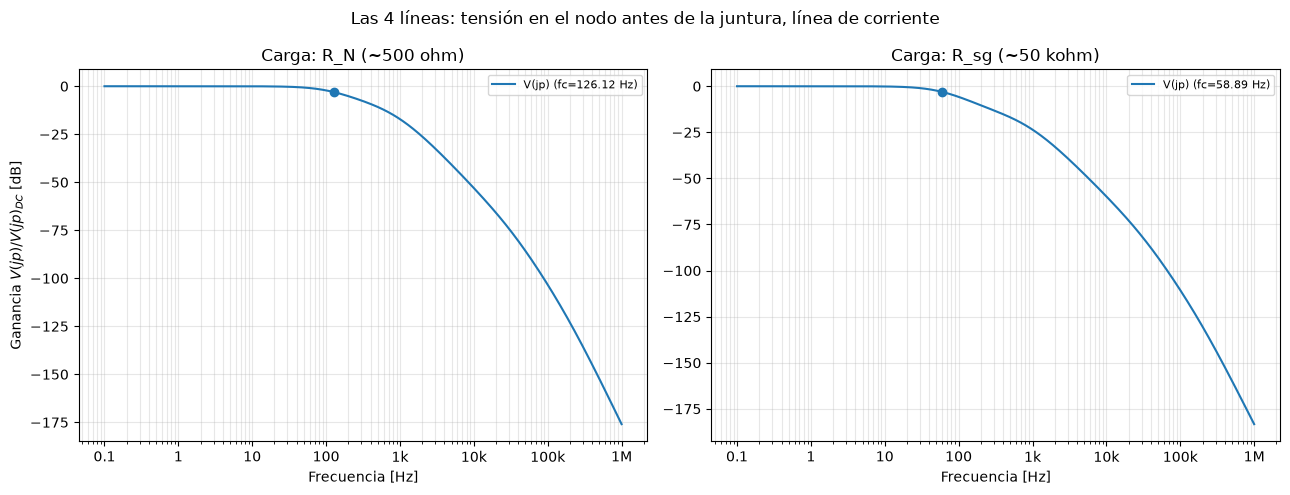

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, (nombre, R_load) in zip(axs, [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]):
    g0 = abs(cuatro_lineas(1e-4, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J))
    vals_db = 20 * np.log10(np.array([abs(cuatro_lineas(f, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J)) for f in frecuencias_z]) / g0)
    fc_jp = frecuencia_de_corte(lambda f: cuatro_lineas(f, 150.0, 2.2e-6, R_cry, C_cry, R_load, C_J))
    linea, = ax.semilogx(frecuencias_z, vals_db, label=f"V(jp) (fc={fc_jp:.2f} Hz)")
    ax.scatter(fc_jp, -3.0, color=linea.get_color(), zorder=5)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_title(f"Carga: {nombre}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which="both")
    ejes_legibles(ax, y=False)
axs[0].set_ylabel(r"Ganancia $V(jp)/V(jp)_{DC}$ [dB]")
fig.suptitle("Las 4 líneas: tensión en el nodo antes de la juntura, línea de corriente")
plt.tight_layout()
plt.show()

### 4b. Barrido en $R_{load}$, y $\tau$

Mismo circuito y salida que en la sección 4 ($V(jp)$), barriendo $R_{load}$. A diferencia de las secciones 1c/2c/3c, acá **no converge** al $f_c$ del caso abierto de 2 líneas (170,1 Hz) ni con $R_{load}\to\infty$ — se estabiliza en $\approx$58 Hz, por la fuga de la línea de sensado ya explicada en la sección 4.

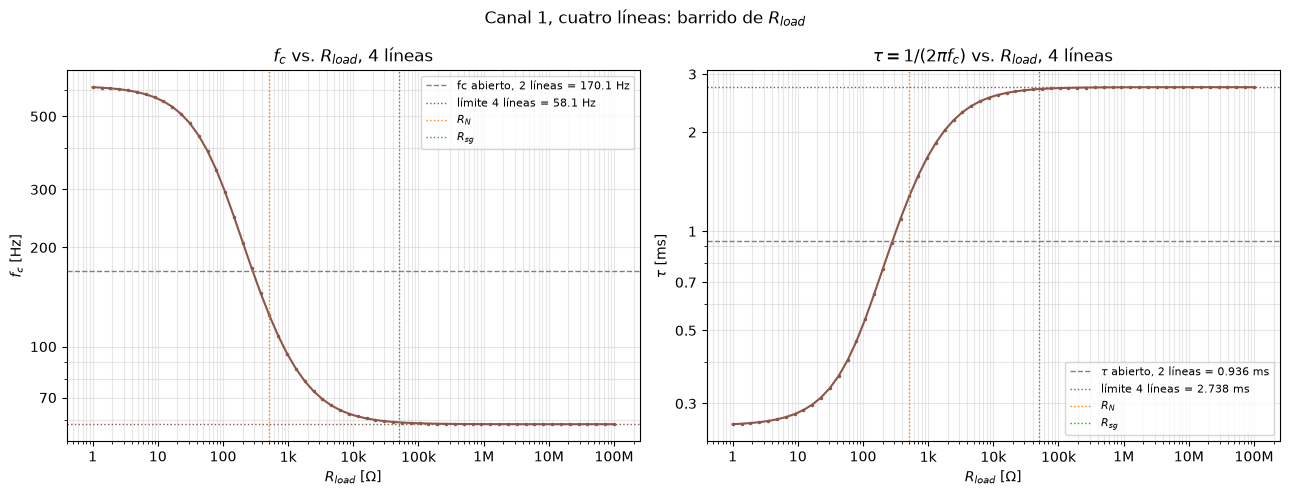

In [38]:
R_loads_barrido_4l = np.logspace(0, 8, 60)
fcs_barrido_4l = [fc_seguro(lambda f: cuatro_lineas(f, 150.0, 2.2e-6, R_cry, C_cry, Rl, C_J)) for Rl in R_loads_barrido_4l]
taus_barrido_4l = 1000.0 / (2 * np.pi * np.array(fcs_barrido_4l))
fc_4l_limite = fcs_barrido_4l[-1]
tau_4l_limite = taus_barrido_4l[-1]

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].loglog(R_loads_barrido_4l, fcs_barrido_4l, marker='.', markersize=3, color="C5")
axs[0].axhline(fc_completo_abierto_c1, color="gray", linestyle="--", linewidth=1, label=f"fc abierto, 2 líneas = {fc_completo_abierto_c1:.1f} Hz")
axs[0].axhline(fc_4l_limite, color="C5", linestyle=":", linewidth=1, label=f"límite 4 líneas = {fc_4l_limite:.1f} Hz")
axs[0].axvline(R_N, color="C1", linestyle=":", linewidth=1, label="$R_N$")
axs[0].axvline(R_sg, color="C2", linestyle=":", linewidth=1, label="$R_{sg}$")
axs[0].set_xlabel(r"$R_{load}$ [$\Omega$]")
axs[0].set_ylabel("$f_c$ [Hz]")
axs[0].set_title("$f_c$ vs. $R_{load}$, 4 líneas")
axs[0].legend(fontsize=8)
axs[0].grid(alpha=0.3, which="both")
ejes_legibles(axs[0])

axs[1].loglog(R_loads_barrido_4l, taus_barrido_4l, marker='.', markersize=3, color="C5")
axs[1].axhline(tau_ms_completo, color="gray", linestyle="--", linewidth=1, label=f"$\\tau$ abierto, 2 líneas = {tau_ms_completo:.3f} ms")
axs[1].axhline(tau_4l_limite, color="C5", linestyle=":", linewidth=1, label=f"límite 4 líneas = {tau_4l_limite:.3f} ms")
axs[1].axvline(R_N, color="C1", linestyle=":", linewidth=1, label="$R_N$")
axs[1].axvline(R_sg, color="C2", linestyle=":", linewidth=1, label="$R_{sg}$")
axs[1].set_xlabel(r"$R_{load}$ [$\Omega$]")
axs[1].set_ylabel(r"$\tau$ [ms]")
axs[1].set_title(r"$\tau=1/(2\pi f_c)$ vs. $R_{load}$, 4 líneas")
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.3, which="both")
ejes_legibles(axs[1])

fig.suptitle("Canal 1, cuatro líneas: barrido de $R_{load}$")
plt.tight_layout()
plt.show()

## Resumen

- Ambiente y cry solos, circuito abierto: coinciden con la tesis (< 0,5% de diferencia).
- $\tau$ del arreglo completo: la tesis lo estima con la aproximación de polo dominante (usa el $f_c$ del ambiente solo, que es el que domina) y da 0,88 ms — coincide con nuestro cálculo de esa misma aproximación (0,8818 ms). El $\tau$ exacto de la cadena completa (ambiente+cry) da 0,9355 ms, un poco más alto porque encadenar dos filtros baja el $f_c$ más de lo que la aproximación captura.
- Con la juntura conectada, $f_c$ se mantiene cerca del abierto en $R_{sg}$ (0,1%–1,3% según la sección) y se aleja más en $R_N$ (hasta +90%) — consistente con "sin variación significativa" de la Sección 5.3.
- Con las cuatro líneas reales, $f_c$ no converge al caso abierto ni con $R_{load}\to\infty$: la línea de sensado aporta un camino de fuga entre $jp$/$jn$ independiente de la carga (capacitores propios de su etapa ambiente y de su etapa cry).